In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

os.listdir('/content/drive/MyDrive/Bluestock_MF_Capstone')

['data']

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
%matplotlib inline

In [ ]:
os.listdir('/content/drive/MyDrive/Bluestock_MF_Capstone/data')

['raw', 'cleaned']

In [ ]:
os.listdir('/content/drive/MyDrive/Bluestock_MF_Capstone/data/cleaned')

['02_nav_history.csv',
 '03_aum_by_fund_house.csv',
 '04_monthly_sip_inflows.csv',
 '05_category_inflows.csv',
 '06_industry_folio_count.csv',
 '07_scheme_performance.csv',
 '08_investor_transactions.csv',
 '09_portfolio_holdings.csv',
 '10_benchmark_indices.csv',
 '01_fund_master.csv']

In [ ]:
base_path = "/content/drive/MyDrive/Bluestock_MF_Capstone/data/cleaned/"

fund_master = pd.read_csv(base_path + "01_fund_master.csv")
nav_history = pd.read_csv(base_path + "02_nav_history.csv")
aum = pd.read_csv(base_path + "03_aum_by_fund_house.csv")
sip = pd.read_csv(base_path + "04_monthly_sip_inflows.csv")
category = pd.read_csv(base_path + "05_category_inflows.csv")
folio = pd.read_csv(base_path + "06_industry_folio_count.csv")
performance = pd.read_csv(base_path + "07_scheme_performance.csv")
transactions = pd.read_csv(base_path + "08_investor_transactions.csv")
portfolio = pd.read_csv(base_path + "09_portfolio_holdings.csv")
benchmark = pd.read_csv(base_path + "10_benchmark_indices.csv")

In [ ]:
datasets = {
    "Fund Master": fund_master,
    "NAV History": nav_history,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Folio": folio,
    "Performance": performance,
    "Transactions": transactions,
    "Portfolio": portfolio,
    "Benchmark": benchmark
}

for name, df in datasets.items():
    print(f"{name:<15} : {df.shape}")

Fund Master     : (40, 15)
NAV History     : (46000, 3)
AUM             : (90, 5)
SIP             : (48, 6)
Category        : (144, 3)
Folio           : (21, 6)
Performance     : (40, 19)
Transactions    : (32778, 13)
Portfolio       : (322, 8)
Benchmark       : (8050, 3)


In [ ]:
print(aum.columns)

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='object')


In [ ]:
nav_history["date"] = pd.to_datetime(nav_history["date"])

aum["date"] = pd.to_datetime(aum["date"])

sip["month"] = pd.to_datetime(sip["month"])

benchmark["date"] = pd.to_datetime(benchmark["date"])

In [ ]:
top5_funds = fund_master["scheme_name"].head(5).tolist()

top5_codes = fund_master["amfi_code"].head(5).tolist()

print(top5_funds)

['SBI Bluechip Fund - Regular Plan - Growth', 'SBI Bluechip Fund - Direct Plan - Growth', 'SBI Small Cap Fund - Regular Plan - Growth', 'SBI Small Cap Fund - Direct Plan - Growth', 'SBI Magnum Gilt Fund - Regular Plan - Growth']


In [ ]:
nav_top5 = nav_history[
    nav_history["amfi_code"].isin(top5_codes)
].copy()

nav_top5.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [ ]:
nav_top5 = nav_top5.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

nav_top5.head()

,amfi_code,date,nav,scheme_name
0,119551,2022-01-03,54.3856,SBI Bluechip Fund - Regular Plan - Growth
1,119551,2022-01-04,54.3474,SBI Bluechip Fund - Regular Plan - Growth
2,119551,2022-01-05,54.6869,SBI Bluechip Fund - Regular Plan - Growth
3,119551,2022-01-06,55.4550,SBI Bluechip Fund - Regular Plan - Growth
4,119551,2022-01-07,55.3692,SBI Bluechip Fund - Regular Plan - Growth


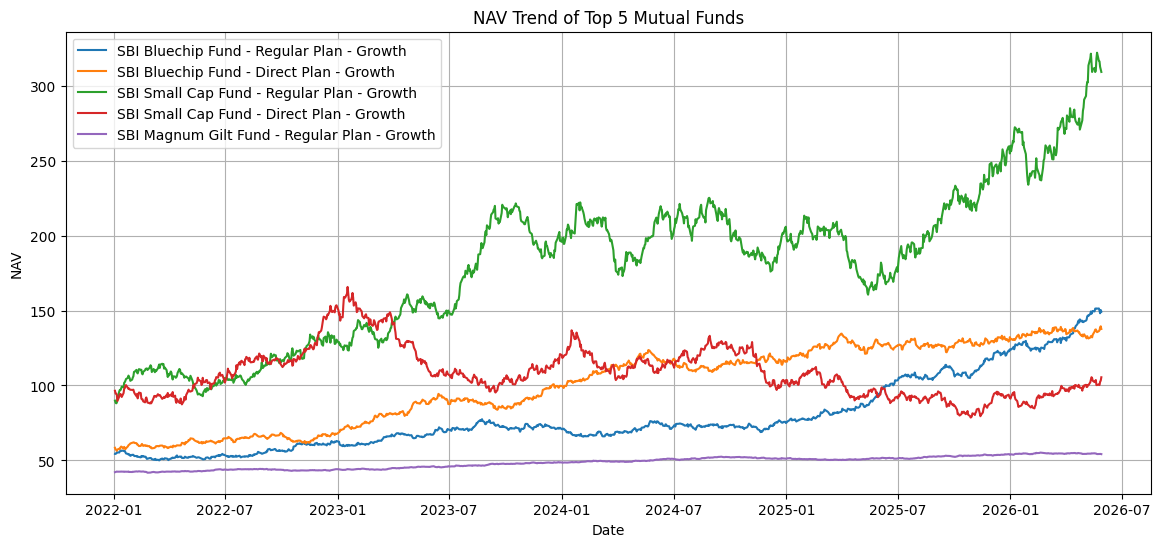

In [ ]:
plt.figure(figsize=(14,6))

for fund in nav_top5["scheme_name"].unique():
    temp = nav_top5[nav_top5["scheme_name"] == fund]
    plt.plot(temp["date"], temp["nav"], label=fund)

plt.title("NAV Trend of Top 5 Mutual Funds")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()
plt.grid(True)

plt.show()

Observation:

Top 5 mutual funds show an overall upward NAV trend over the analysis period.

Some funds exhibit higher volatility, while others demonstrate more stable growth.

The visualization helps compare long-term performance across selected schemes.

In [ ]:
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [ ]:
aum.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            90 non-null     datetime64[ns]
 1   fund_house      90 non-null     object        
 2   aum_lakh_crore  90 non-null     float64       
 3   aum_crore       90 non-null     int64         
 4   num_schemes     90 non-null     int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 3.6+ KB


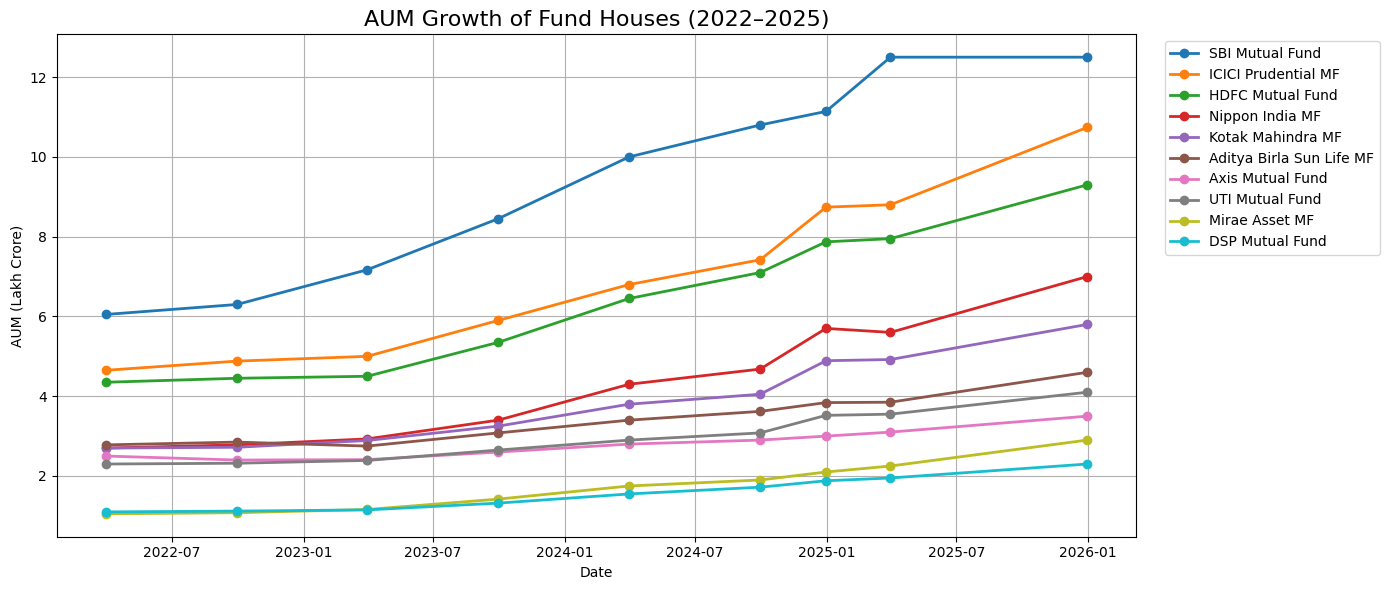

In [ ]:
plt.figure(figsize=(14,6))

for fund in aum["fund_house"].unique():
    temp = aum[aum["fund_house"] == fund]
    plt.plot(
        temp["date"],
        temp["aum_lakh_crore"],
        marker="o",
        linewidth=2,
        label=fund
    )

plt.title("AUM Growth of Fund Houses (2022–2025)", fontsize=16)
plt.xlabel("Date")
plt.ylabel("AUM (Lakh Crore)")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")

plt.tight_layout()
plt.show()

In [ ]:
sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,NaN
1,2022-02-01,11438,4.93,8.20,4.85,NaN
2,2022-03-01,12328,5.09,10.50,5.01,NaN
3,2022-04-01,11863,5.48,9.52,5.12,NaN
4,2022-05-01,12286,5.55,8.10,5.15,NaN


In [ ]:
sip.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   month                      48 non-null     datetime64[ns]
 1   sip_inflow_crore           48 non-null     int64         
 2   active_sip_accounts_crore  48 non-null     float64       
 3   new_sip_accounts_lakh      48 non-null     float64       
 4   sip_aum_lakh_crore         48 non-null     float64       
 5   yoy_growth_pct             36 non-null     float64       
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 2.4 KB


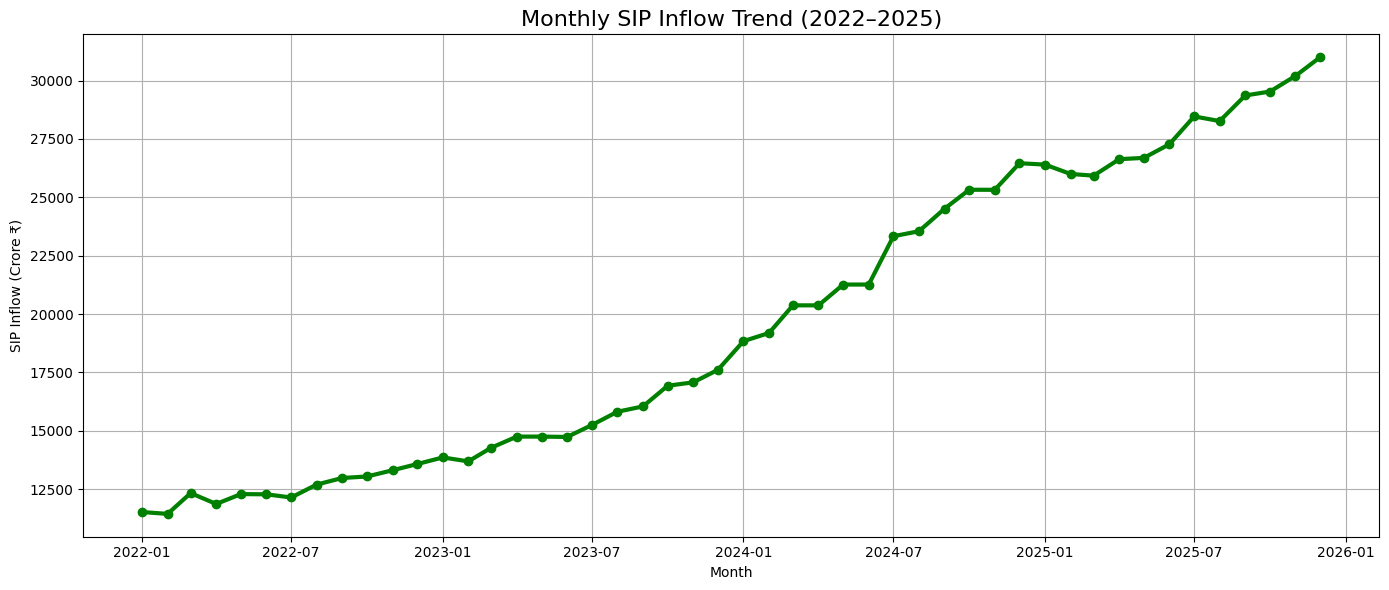

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"],
    color="green",
    linewidth=3,
    marker="o"
)

plt.title("Monthly SIP Inflow Trend (2022–2025)", fontsize=16)

plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore ₹)")

plt.grid(True)

plt.tight_layout()

plt.show()

### Observation

- Monthly SIP inflows show a consistent upward trend from 2022 to 2025.
- Investor participation increased steadily over the period.
- The highest SIP inflow was recorded towards the end of the analysis period.
- This indicates increasing investor confidence in mutual funds.

### Business Insight

The continuous rise in SIP inflows reflects strong retail investor participation and sustained confidence in the Indian mutual fund industry. Asset Management Companies (AMCs) can leverage this trend by expanding SIP-focused investment products and strengthening customer acquisition strategies.

In [ ]:
category.head()

,month,category,net_inflow_crore
0,2024-04-01,Large Cap,2413.0
1,2024-04-01,Mid Cap,3897.0
2,2024-04-01,Small Cap,3533.0
3,2024-04-01,Flexi Cap,4947.0
4,2024-04-01,Large & Mid Cap,4214.0


In [ ]:
category.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   month             144 non-null    object 
 1   category          144 non-null    object 
 2   net_inflow_crore  144 non-null    float64
dtypes: float64(1), object(2)
memory usage: 3.5+ KB


In [ ]:
category.columns

Index(['month', 'category', 'net_inflow_crore'], dtype='object')

In [ ]:
category["month"] = pd.to_datetime(category["month"])

In [ ]:
heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

heatmap_data.head()

month,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


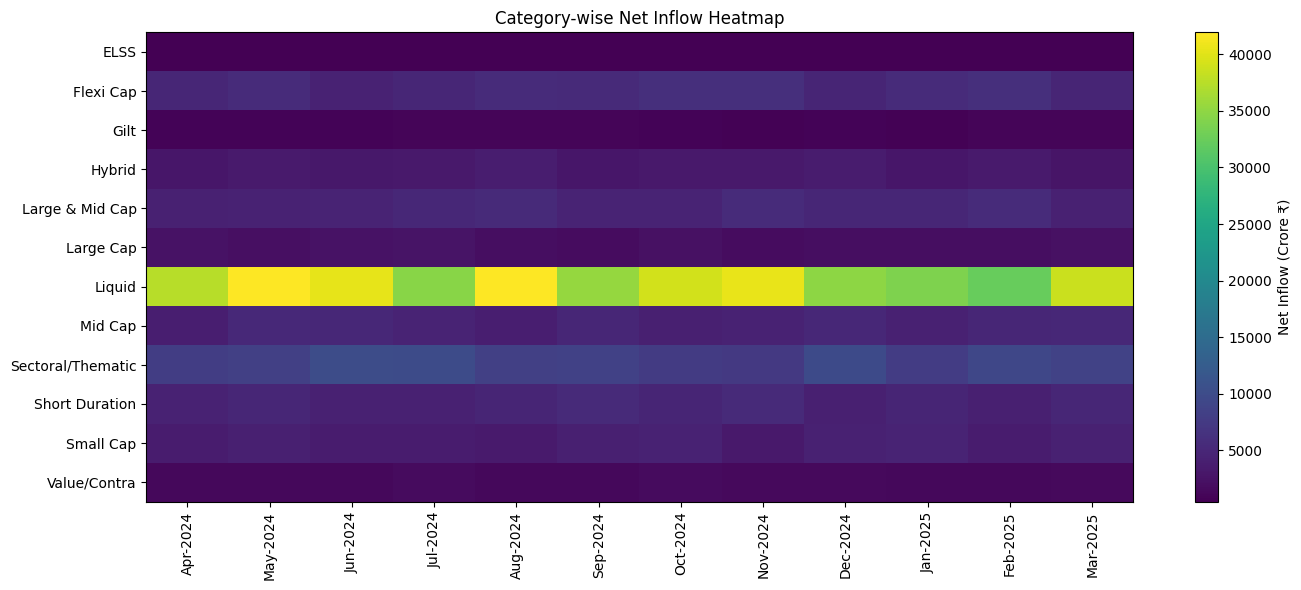

In [ ]:
plt.figure(figsize=(14,6))

plt.imshow(
    heatmap_data,
    aspect="auto"
)

plt.colorbar(label="Net Inflow (Crore ₹)")

plt.xticks(
    range(len(heatmap_data.columns)),
    heatmap_data.columns.strftime("%b-%Y"),
    rotation=90
)

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

plt.title("Category-wise Net Inflow Heatmap")

plt.tight_layout()

plt.show()

### Observation

- Flexi Cap, Large & Mid Cap, and Mid Cap categories show consistently high net inflows.
- Some categories experience periods of relatively lower inflows.
- Net inflows vary across categories and over time, reflecting changing investor preferences.

### Business Insight

Fund categories with consistently strong inflows represent sustained investor demand and can be prioritized for marketing and product development. Monitoring category-wise trends also helps identify shifts in investment preferences over time.

In [ ]:
folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01-01,13.26,9.28,1.86,0.80,1.33
1,2022-04-01,13.91,9.74,1.95,0.83,1.39
2,2022-07-01,13.85,9.69,1.94,0.83,1.38
3,2022-10-01,14.12,9.88,1.98,0.85,1.41
4,2023-01-01,14.81,10.37,2.07,0.89,1.48


In [ ]:
folio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   month                21 non-null     object 
 1   total_folios_crore   21 non-null     float64
 2   equity_folios_crore  21 non-null     float64
 3   debt_folios_crore    21 non-null     float64
 4   hybrid_folios_crore  21 non-null     float64
 5   others_folios_crore  21 non-null     float64
dtypes: float64(5), object(1)
memory usage: 1.1+ KB


In [ ]:
folio.columns

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='object')

In [ ]:
folio["month"] = pd.to_datetime(folio["month"])

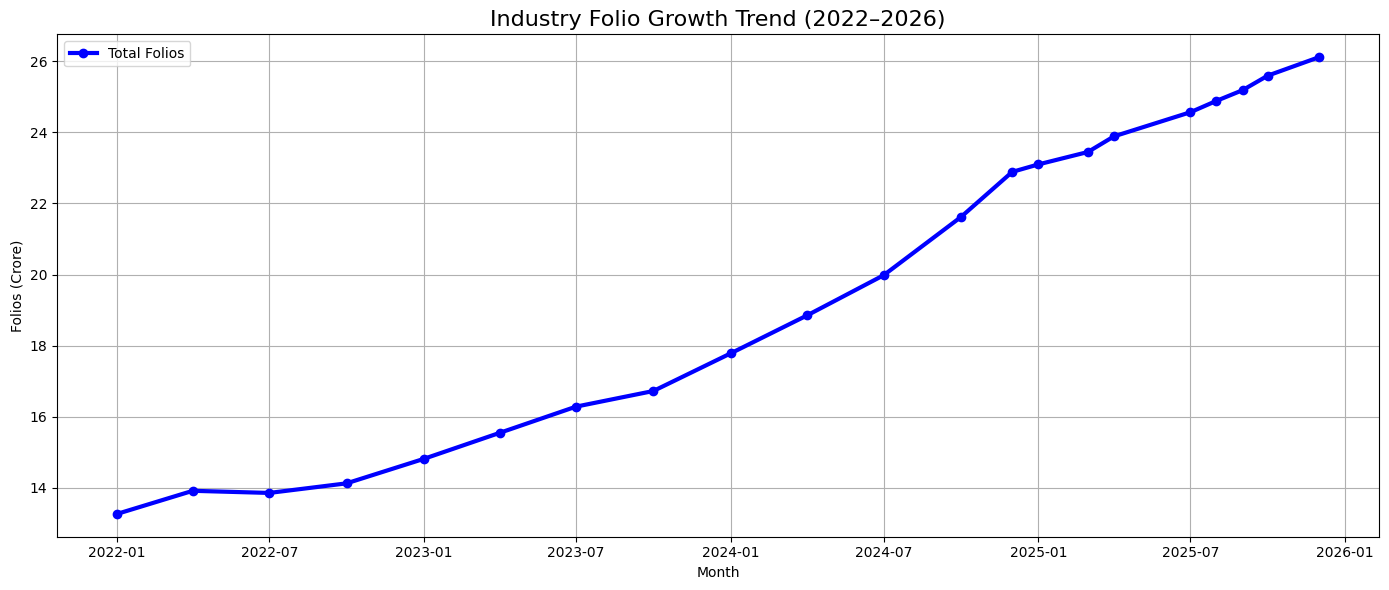

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o",
    linewidth=3,
    color="blue",
    label="Total Folios"
)

plt.title("Industry Folio Growth Trend (2022–2026)", fontsize=16)

plt.xlabel("Month")
plt.ylabel("Folios (Crore)")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

### Observation

- Total mutual fund folios increased steadily throughout the analysis period.
- Investor participation showed consistent long-term growth.
- The upward trend indicates increasing adoption of mutual fund investments in India.

### Business Insight

The steady rise in folio count reflects a growing retail investor base. This indicates increasing market penetration of mutual funds and highlights opportunities for Asset Management Companies (AMCs) to expand customer acquisition and retention strategies.

In [ ]:
performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [ ]:
performance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   scheme_name         40 non-null     object 
 2   fund_house          40 non-null     object 
 3   category            40 non-null     object 
 4   plan                40 non-null     object 
 5   return_1yr_pct      40 non-null     float64
 6   return_3yr_pct      40 non-null     float64
 7   return_5yr_pct      40 non-null     float64
 8   benchmark_3yr_pct   40 non-null     float64
 9   alpha               40 non-null     float64
 10  beta                40 non-null     float64
 11  sharpe_ratio        40 non-null     float64
 12  sortino_ratio       40 non-null     float64
 13  std_dev_ann_pct     40 non-null     float64
 14  max_drawdown_pct    40 non-null     float64
 15  aum_crore           40 non-null     int64  
 16  expense_ra

In [ ]:
performance.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')

In [ ]:
performance.describe()

,amfi_code,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating
count,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.00000,40.000000,40.000000
mean,120247.000000,14.376000,14.089000,14.516750,12.835500,1.253500,0.873250,1.361750,2.082500,14.962500,-19.200250,26091.60000,1.237000,4.250000
std,14534.998667,4.883023,4.617253,4.454021,4.740972,0.447412,0.224846,1.475805,2.203144,6.669282,8.819164,13809.11134,0.386584,0.742484
min,100016.000000,4.260000,5.140000,5.430000,3.960000,0.510000,0.220000,0.800000,1.030000,0.500000,-33.500000,979.00000,0.550000,3.000000
25%,118632.750000,11.735000,12.035000,12.340000,10.690000,0.887500,0.890000,0.865000,1.270000,14.000000,-25.062500,17400.50000,0.787500,4.000000
50%,119551.500000,14.620000,14.205000,14.185000,13.090000,1.205000,0.960000,0.925000,1.445000,14.000000,-20.600000,26713.00000,1.425000,4.000000
75%,120842.250000,16.392500,15.882500,17.585000,14.775000,1.700000,1.000000,0.985000,1.637500,19.000000,-14.255000,38125.00000,1.540000,5.000000
max,149324.000000,24.930000,23.390000,23.800000,22.160000,1.980000,1.040000,7.680000,10.370000,25.000000,-2.230000,49046.00000,1.640000,5.000000


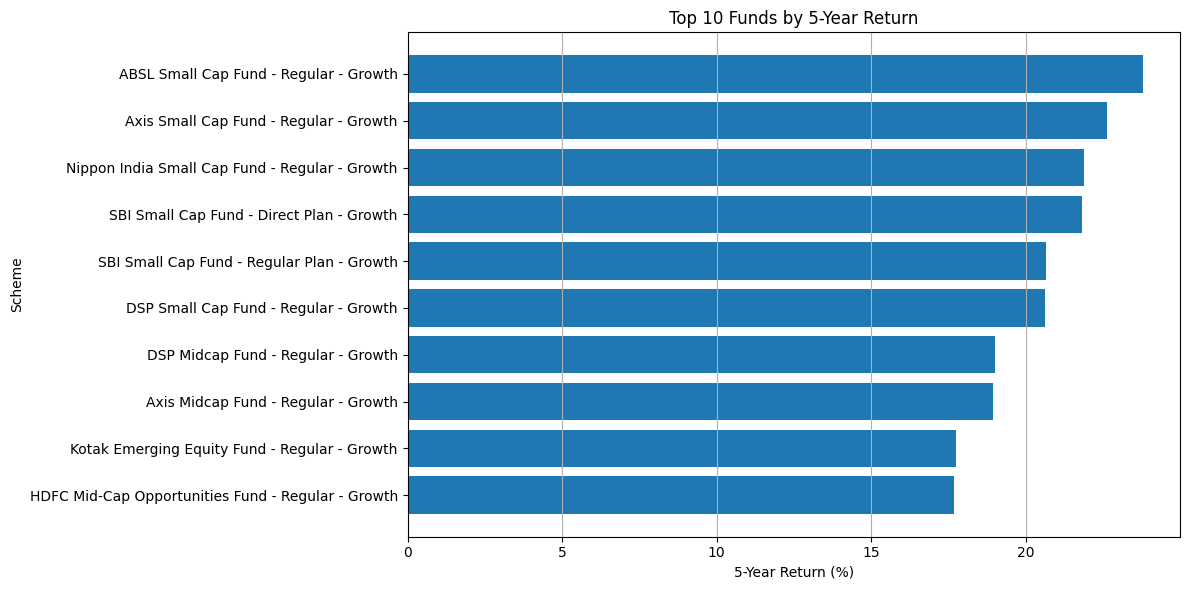

In [ ]:
top10 = (
    performance
    .sort_values("return_5yr_pct", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

plt.barh(
    top10["scheme_name"],
    top10["return_5yr_pct"]
)

plt.xlabel("5-Year Return (%)")
plt.ylabel("Scheme")
plt.title("Top 10 Funds by 5-Year Return")

plt.gca().invert_yaxis()

plt.grid(axis="x")

plt.tight_layout()

plt.show()

### Observation

- Small Cap funds dominate the top 10 based on 5-year returns.
- Equity-oriented schemes outperform debt-oriented schemes over the long term.
- Long-term returns vary significantly across fund categories.

### Business Insight

Investors seeking higher long-term returns may prefer high-performing equity funds. However, these funds should also be evaluated with risk metrics such as volatility and maximum drawdown before making investment decisions.

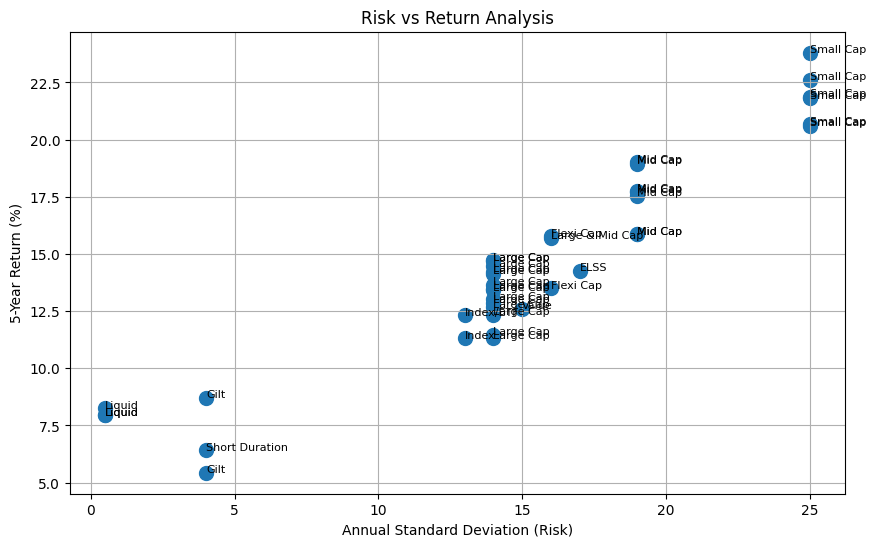

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(
    performance["std_dev_ann_pct"],
    performance["return_5yr_pct"],
    s=100
)

for i in range(len(performance)):
    plt.text(
        performance["std_dev_ann_pct"].iloc[i],
        performance["return_5yr_pct"].iloc[i],
        performance["category"].iloc[i],
        fontsize=8
    )

plt.xlabel("Annual Standard Deviation (Risk)")
plt.ylabel("5-Year Return (%)")

plt.title("Risk vs Return Analysis")

plt.grid(True)

plt.show()

### Observation

- Higher returns are generally associated with higher risk.
- Gilt funds occupy the low-risk, low-return region.
- Small Cap funds deliver higher returns but also exhibit greater volatility.

In [ ]:
portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [ ]:
portfolio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   amfi_code          322 non-null    int64  
 1   stock_symbol       322 non-null    object 
 2   stock_name         322 non-null    object 
 3   sector             322 non-null    object 
 4   weight_pct         322 non-null    float64
 5   market_value_cr    322 non-null    float64
 6   current_price_inr  322 non-null    float64
 7   portfolio_date     322 non-null    object 
dtypes: float64(3), int64(1), object(4)
memory usage: 20.3+ KB


In [ ]:
portfolio.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')

In [ ]:
portfolio.describe(include="all")

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
count,322.000000,322,322,322,322.000000,322.000000,322.000000,322
unique,NaN,30,30,14,NaN,NaN,NaN,1
top,NaN,BHARTIARTL,Bharti Airtel Ltd,Banking,NaN,NaN,NaN,2025-12-31
freq,NaN,15,15,60,NaN,NaN,NaN,322
mean,121210.434783,NaN,NaN,NaN,10.558975,1008.846646,4080.870528,NaN
std,14669.377920,NaN,NaN,NaN,6.060137,543.827535,2265.186353,NaN
min,100016.000000,NaN,NaN,NaN,0.990000,55.740000,246.780000,NaN
25%,118633.000000,NaN,NaN,NaN,6.015000,513.702500,2081.985000,NaN
50%,119552.000000,NaN,NaN,NaN,9.395000,1045.670000,4138.995000,NaN
75%,120842.750000,NaN,NaN,NaN,13.917500,1477.502500,5914.307500,NaN


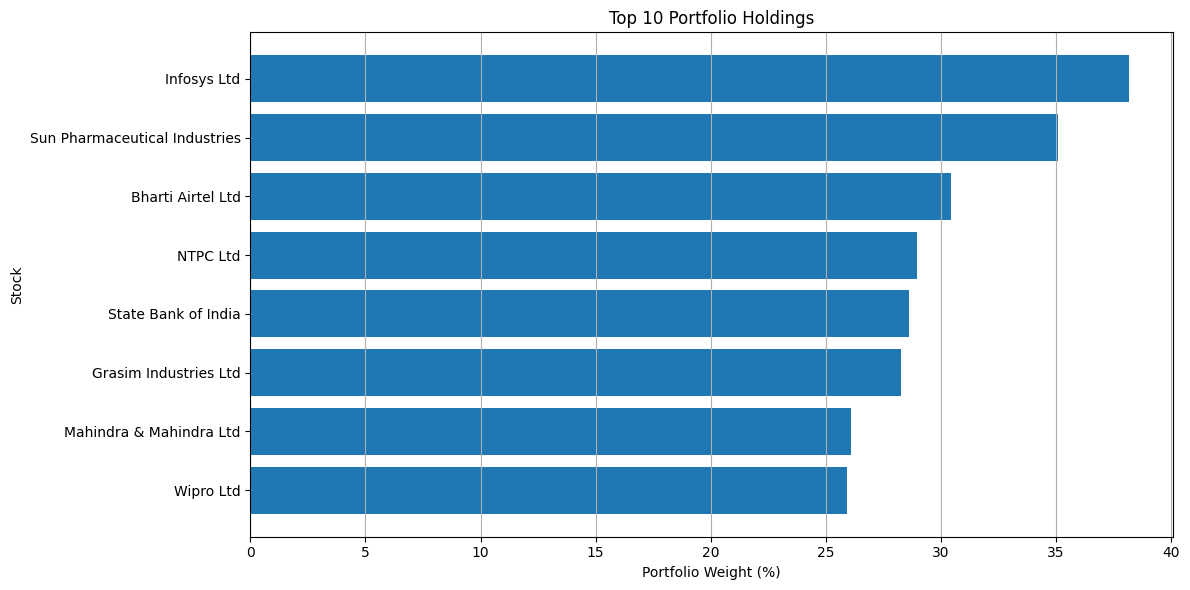

In [ ]:
top_holdings = (
    portfolio
    .sort_values("weight_pct", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

plt.barh(
    top_holdings["stock_name"],
    top_holdings["weight_pct"]
)

plt.gca().invert_yaxis()

plt.xlabel("Portfolio Weight (%)")
plt.ylabel("Stock")

plt.title("Top 10 Portfolio Holdings")

plt.grid(axis="x")

plt.tight_layout()

plt.show()

### Observation

- The portfolio is concentrated in a few large-cap holdings.
- Power Grid Corporation and HDFC Bank are among the highest-weighted holdings.
- Top holdings contribute a significant share of the portfolio allocation.

### Business Insight

High allocation to a few companies indicates portfolio concentration. Portfolio managers should periodically review concentration risk and ensure adequate diversification across sectors and securities.

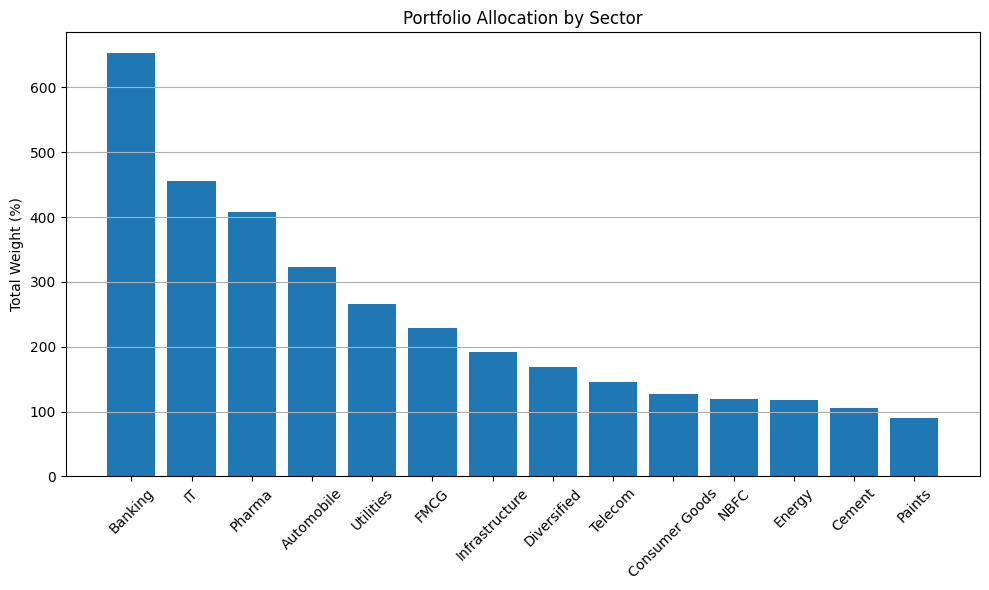

In [ ]:
sector_weight = (
    portfolio
    .groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

plt.bar(
    sector_weight.index,
    sector_weight.values
)

plt.xticks(rotation=45)

plt.ylabel("Total Weight (%)")

plt.title("Portfolio Allocation by Sector")

plt.grid(axis="y")

plt.tight_layout()

plt.show()

### Observation

- Banking and Financial Services constitute a significant portion of the portfolio.
- Multiple sectors are represented, indicating diversification.
- Sector allocation is not evenly distributed across all industries.

### Business Insight

Sector-wise allocation helps assess diversification. Overexposure to a single sector can increase portfolio risk, while balanced exposure improves long-term stability.

In [ ]:
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [ ]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   investor_id         32778 non-null  object 
 1   transaction_date    32778 non-null  object 
 2   amfi_code           32778 non-null  int64  
 3   transaction_type    32778 non-null  object 
 4   amount_inr          32778 non-null  int64  
 5   state               32778 non-null  object 
 6   city                32778 non-null  object 
 7   city_tier           32778 non-null  object 
 8   age_group           32778 non-null  object 
 9   gender              32778 non-null  object 
 10  annual_income_lakh  32778 non-null  float64
 11  payment_mode        32778 non-null  object 
 12  kyc_status          32778 non-null  object 
dtypes: float64(1), int64(2), object(10)
memory usage: 3.3+ MB


In [ ]:
transactions.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')

In [ ]:
transactions.describe(include="all")

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
count,32778,32778,32778.000000,32778,32778.000000,32778,32778,32778,32778,32778,32778.000000,32778,32778
unique,5000,516,NaN,3,NaN,12,24,2,5,2,NaN,4,2
top,INV001497,2025-04-28,NaN,SIP,NaN,Punjab,Kolkata,T30,26-35,Male,NaN,Net Banking,Verified
freq,12,88,NaN,19716,NaN,2965,2748,21719,13463,21809,NaN,8250,30146
mean,NaN,NaN,120264.617518,NaN,107437.318628,NaN,NaN,NaN,NaN,NaN,26.181219,NaN,NaN
std,NaN,NaN,14370.205345,NaN,150415.905084,NaN,NaN,NaN,NaN,NaN,20.805425,NaN,NaN
min,NaN,NaN,100016.000000,NaN,400.000000,NaN,NaN,NaN,NaN,NaN,3.000000,NaN,NaN
25%,NaN,NaN,118632.000000,NaN,3153.000000,NaN,NaN,NaN,NaN,NaN,10.600000,NaN,NaN
50%,NaN,NaN,119551.000000,NaN,17782.500000,NaN,NaN,NaN,NaN,NaN,19.700000,NaN,NaN
75%,NaN,NaN,120843.000000,NaN,189324.250000,NaN,NaN,NaN,NaN,NaN,37.400000,NaN,NaN


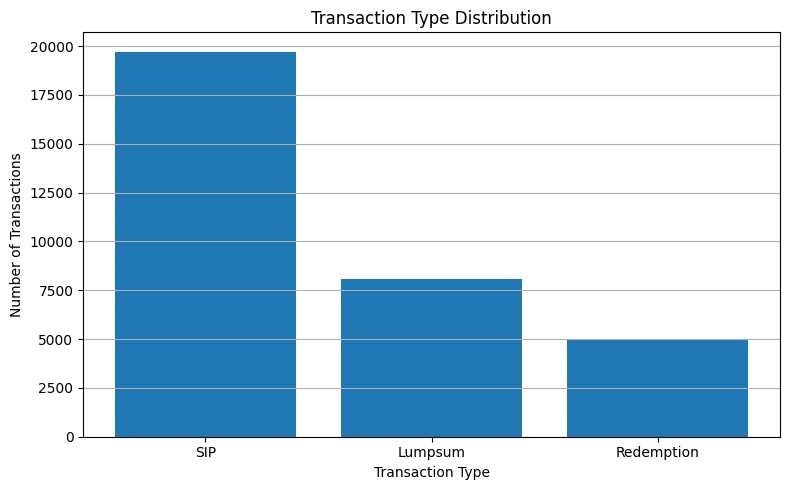

In [ ]:
txn_type = transactions["transaction_type"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(
    txn_type.index,
    txn_type.values
)

plt.title("Transaction Type Distribution")

plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.grid(axis="y")

plt.tight_layout()

plt.show()

### Observation

- SIP transactions account for the largest share of total transactions.
- Redemption and Lumpsum transactions occur less frequently.
- Investors show a strong preference for systematic investing.

### Business Insight

The dominance of SIP transactions reflects disciplined long-term investment behaviour. AMCs should continue promoting SIP products to strengthen customer retention and recurring investments.

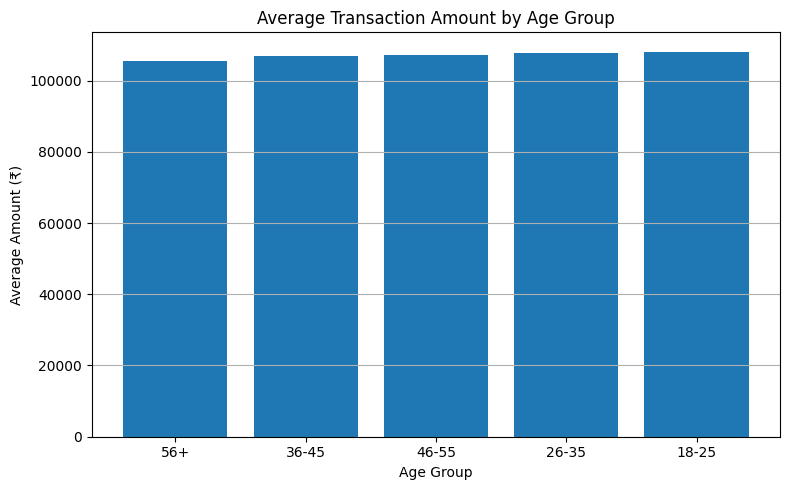

In [ ]:
age_amount = (
    transactions
    .groupby("age_group")["amount_inr"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(8,5))

plt.bar(
    age_amount.index,
    age_amount.values
)

plt.title("Average Transaction Amount by Age Group")

plt.xlabel("Age Group")
plt.ylabel("Average Amount (₹)")

plt.grid(axis="y")

plt.tight_layout()

plt.show()

### Observation

- Average investment amount differs across age groups.
- Middle-aged investors generally contribute higher investment amounts.
- Younger investors tend to invest smaller amounts.

### Business Insight

Age-based investment behaviour can help AMCs design targeted financial products and personalized marketing campaigns for different investor segments.

In [ ]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

In [ ]:
print(benchmark.columns)

Index(['date', 'index_name', 'close_value'], dtype='object')


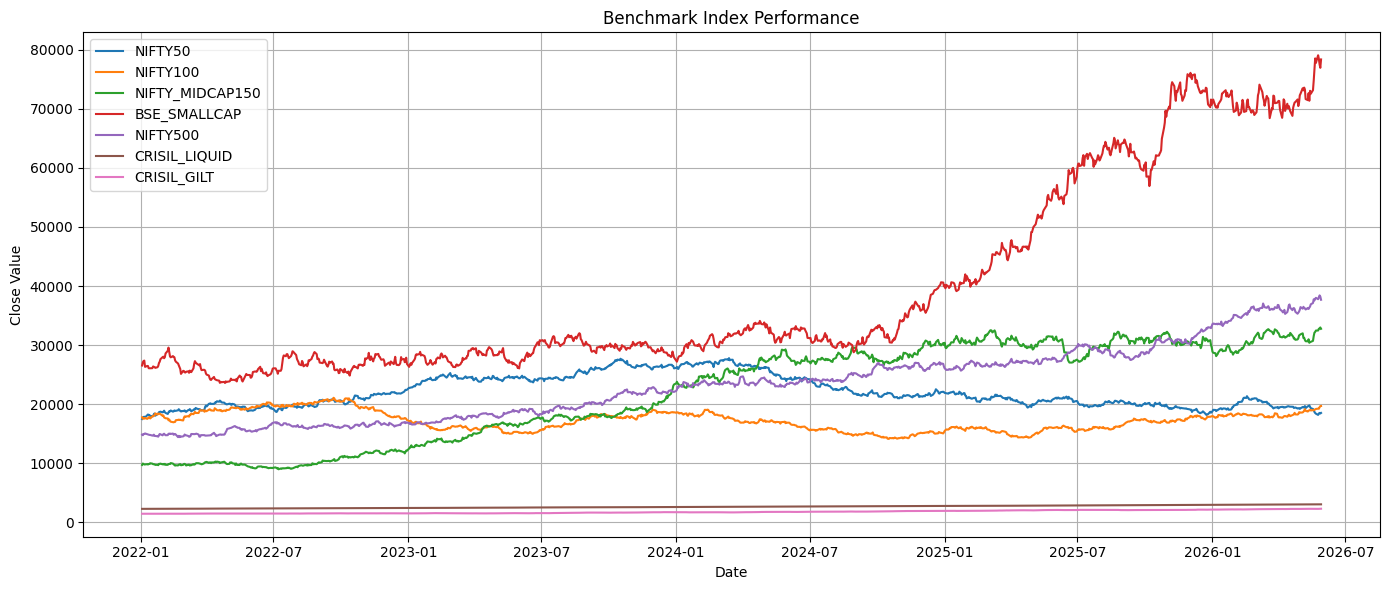

In [ ]:
plt.figure(figsize=(14,6))

for idx in benchmark["index_name"].unique():

    temp = benchmark[benchmark["index_name"] == idx]

    plt.plot(
        temp["date"],
        temp["close_value"],   # <-- Yahi change karna hai
        label=idx
    )

plt.title("Benchmark Index Performance")

plt.xlabel("Date")
plt.ylabel("Close Value")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()